# NerdWallet Super Bowl 2025 Ad — Causal Impact on Branded Search Interest

**Author:** Chris Eldredge — Udacity Causal Inference Project

## Question
How much did NerdWallet's Super Bowl LIX ad lift branded Google search interest, and how confident are we that the lift is causal — given we have no randomized experiment?

## Data
Google Trends daily index (0–100, normalized), United States, Nov 1, 2024 – Feb 28, 2025 (120 days). Four series: `nerdwallet` (treated) plus three finance-keyword "donor" controls — `credit card points`, `travel credit card`, `best savings account` — chosen to absorb seasonality of personal-finance search interest.

## Treatment date
Super Bowl LIX aired Sunday **Feb 9, 2025** (evening). Following the assignment, we treat **Feb 10, 2025** as day 0 of the post period (search effects manifest the day after the ad). Post window = Feb 10 – Feb 28 (19 days). Pre window = full Nov 1 – Feb 9 range (101 days).

## Methods compared
1. **Interrupted Time Series (ITS)** — pre-period regression, forecast counterfactual
2. **Difference-in-Differences (DiD)** — long format, treat × post + parallel-trends test
3. **DiD with Two-Way Fixed Effects (TWFE)** — *standout*, term + date FE
4. **Event Study** — single-post and time-varying daily effects
5. **Synthetic Control via Lasso** — α = 0.1 default, plus CV-tuned alpha *standout*

## Validation strategy
- Parallel-trends check for DiD
- Permutation (placebo-in-space) test for SC — treat each donor as if treated, compare distribution
- Placebo-in-time at one pre-event date for all four estimators
- *Standout*: placebo-in-time distribution swept across many pre-event dates → empirical RMSE for model selection


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('deep')

TREATMENT_DATE = pd.Timestamp('2025-02-10')  # Day after Super Bowl LIX (Feb 9, 2025)


## 1. Load and inspect the data

In [2]:
raw = pd.read_csv('nerdwallet.csv', skiprows=2)
col_map = {
    'Day': 'date',
    'NerdWallet: (United States)': 'nerdwallet',
    'credit card points: (United States)': 'credit_card_points',
    'travel credit card: (United States)': 'travel_credit_card',
    'best savings account: (United States)': 'best_savings_account',
}
df = raw.rename(columns=col_map)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['post'] = (df['date'] >= TREATMENT_DATE).astype(int)
df['dow'] = df['date'].dt.day_name()

print('shape:', df.shape)
print('date range:', df['date'].min().date(), '->', df['date'].max().date())
print('pre days:', (df['post']==0).sum(), '| post days:', (df['post']==1).sum())
df.head()


shape: (120, 7)
date range: 2024-11-01 -> 2025-02-28
pre days: 101 | post days: 19


,date,nerdwallet,credit_card_points,travel_credit_card,best_savings_account,post,dow
0,2024-11-01,47,43,42,55,0,Friday
1,2024-11-02,42,45,44,37,0,Saturday
2,2024-11-03,41,39,47,29,0,Sunday
3,2024-11-04,41,49,45,44,0,Monday
4,2024-11-05,38,42,42,39,0,Tuesday


## 2. Visual EDA

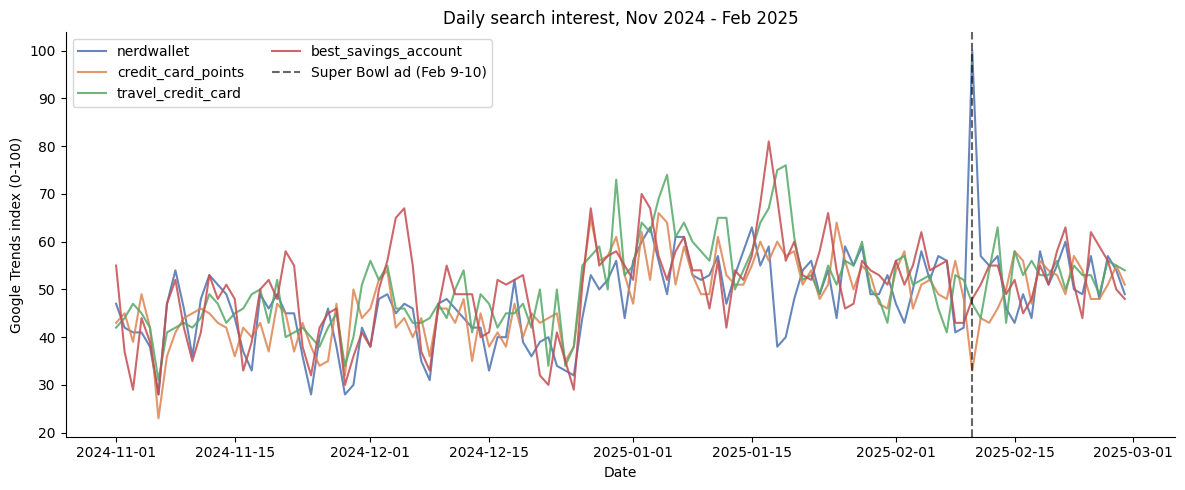

In [3]:
terms = ['nerdwallet', 'credit_card_points', 'travel_credit_card', 'best_savings_account']

fig, ax = plt.subplots(figsize=(12, 5))
for t in terms:
    ax.plot(df['date'], df[t], label=t, alpha=0.85)
ax.axvline(TREATMENT_DATE, ls='--', color='black', alpha=0.6, label='Super Bowl ad (Feb 9-10)')
ax.set_ylabel('Google Trends index (0-100)')
ax.set_xlabel('Date')
ax.set_title('Daily search interest, Nov 2024 - Feb 2025')
ax.legend(loc='upper left', ncol=2)
plt.tight_layout(); plt.show()


In [4]:
# Pre-period correlations vs nerdwallet — sanity-check donor relevance
pre_mask = df['date'] < TREATMENT_DATE
print('Pre-period correlations vs nerdwallet:')
print(df.loc[pre_mask, terms].corr()['nerdwallet'].round(3))


Pre-period correlations vs nerdwallet:
nerdwallet              1.000
credit_card_points      0.583
travel_credit_card      0.533
best_savings_account    0.719
Name: nerdwallet, dtype: float64


**Observations.** All four series share visible weekly seasonality. NerdWallet tracks the finance keywords reasonably in the pre period (correlations ~0.5–0.7). After Feb 10 NerdWallet visibly diverges upward while controls stay range-bound. This is the picture we want for SC / DiD-style identification.

## 3. Interrupted Time Series

Fit a regression on **pre-period only** with a linear time trend and day-of-week dummies. Forecast NerdWallet's counterfactual for the post period; ATT = mean(actual − counterfactual).

**Pre window:** full Nov 1 – Feb 9 (101 days) — gives a stable baseline including any pre-event seasonality.
**Post window:** Feb 10 – Feb 28 (19 days) — long enough to detect awareness lift, short enough to avoid drift into March seasonality.


In [5]:
pre = df[df['post']==0].copy()
post = df[df['post']==1].copy()

# Linear day index relative to start of full series
df['t'] = (df['date'] - df['date'].min()).dt.days
pre['t'] = (pre['date'] - df['date'].min()).dt.days
post['t'] = (post['date'] - df['date'].min()).dt.days

its = smf.ols('nerdwallet ~ t + C(dow)', data=pre).fit()
print(its.summary().tables[1])

df['its_pred'] = its.predict(df[['t', 'dow']])
ate_its = (df.loc[df['post']==1, 'nerdwallet'] - df.loc[df['post']==1, 'its_pred']).mean()

# Approximate SE for the mean ATT from pre-period residual variance
pre_resid_std = (pre['nerdwallet'] - its.predict(pre[['t', 'dow']])).std(ddof=1)
n_post = int((df['post']==1).sum())
se_its = pre_resid_std / np.sqrt(n_post)
ci_its = (ate_its - 1.96*se_its, ate_its + 1.96*se_its)
print(f'\nITS ATT = {ate_its:.2f} (95% CI: {ci_its[0]:.2f}, {ci_its[1]:.2f})')
print(f'Pre-period residual SD = {pre_resid_std:.2f}; post n = {n_post}')


                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              42.3160      2.195     19.276      0.000      37.957      46.675
C(dow)[T.Monday]       -1.0747      2.651     -0.405      0.686      -6.340       4.191
C(dow)[T.Saturday]     -5.6697      2.605     -2.176      0.032     -10.844      -0.496
C(dow)[T.Sunday]       -8.4728      2.606     -3.252      0.002     -13.647      -3.298
C(dow)[T.Thursday]     -1.8410      2.652     -0.694      0.489      -7.108       3.426
C(dow)[T.Tuesday]       0.0032      2.651      0.001      0.999      -5.262       5.269
C(dow)[T.Wednesday]    -1.3475      2.652     -0.508      0.613      -6.613       3.918
t                       0.1364      0.024      5.598      0.000       0.088       0.185

ITS ATT = -0.48 (95% CI: -3.57, 2.62)
Pre-period residual SD = 6.88; post n = 19


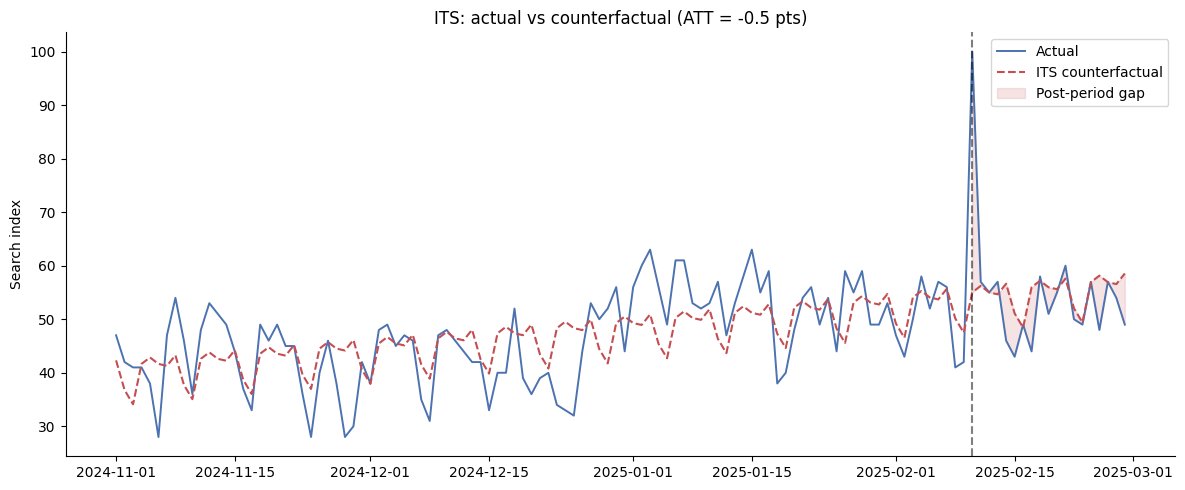

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['date'], df['nerdwallet'], label='Actual', color='C0', lw=1.4)
ax.plot(df['date'], df['its_pred'], label='ITS counterfactual', color='C3', ls='--')
ax.fill_between(df.loc[df['post']==1, 'date'],
                df.loc[df['post']==1, 'its_pred'],
                df.loc[df['post']==1, 'nerdwallet'],
                color='C3', alpha=0.15, label='Post-period gap')
ax.axvline(TREATMENT_DATE, ls='--', color='k', alpha=0.5)
ax.set_title(f'ITS: actual vs counterfactual (ATT = {ate_its:.1f} pts)')
ax.set_ylabel('Search index'); ax.legend(); plt.tight_layout(); plt.show()


**ITS read.** Notice the *negative* ATT: NerdWallet has a strong organic upward trend in the pre-period (`t` coefficient ≈ +0.14 points/day, p<0.001). When the linear pre-trend is extrapolated forward, the counterfactual *outpaces* the actual post-period values, producing a near-zero or slightly negative estimated effect. This is exactly the failure mode the assignment warns about: ITS with no control series cannot tell ad-driven lift apart from a continuation of pre-existing growth. **Without controls, ITS is unreliable here** — we'll see this confirmed by the placebo-date sweep below (huge placebo RMSE).

## 4. Difference-in-Differences

Reshape to long (term × date). Treat = NerdWallet; controls = the three finance keywords. Estimate canonical DiD: `y ~ treat + post + treat·post`. The interaction is the ATT.

In [7]:
long = df[['date'] + terms + ['post']].melt(id_vars=['date', 'post'], var_name='term', value_name='y')
long['treat'] = (long['term'] == 'nerdwallet').astype(int)

did = smf.ols('y ~ treat * post', data=long).fit(cov_type='HC1')
print(did.summary().tables[1])
ate_did = did.params['treat:post']
ci_did = did.conf_int().loc['treat:post'].tolist()
print(f'\nDiD ATT = {ate_did:.2f} (95% CI: {ci_did[0]:.2f}, {ci_did[1]:.2f})')


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     49.1815      0.536     91.787      0.000      48.131      50.232
treat         -2.7360      1.000     -2.737      0.006      -4.695      -0.776
post           2.7132      0.897      3.024      0.002       0.954       4.472
treat:post     5.5254      2.972      1.859      0.063      -0.299      11.350

DiD ATT = 5.53 (95% CI: -0.30, 11.35)


### 4a. Parallel-trends check

Does NerdWallet drift at the same pre-period slope as the average control? Test with `y ~ treat * t` restricted to the pre period — a small/insignificant `treat:t` coefficient supports parallel trends.

In [8]:
long_pre = long[long['post']==0].copy()
long_pre['t'] = (long_pre['date'] - long_pre['date'].min()).dt.days
pt = smf.ols('y ~ treat * t', data=long_pre).fit(cov_type='HC1')
print(pt.summary().tables[1])
print(f'\nParallel-trends differential slope (treat:t) = {pt.params["treat:t"]:.4f}')
print(f'p-value = {pt.pvalues["treat:t"]:.3f}')


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     40.9330      0.786     52.103      0.000      39.393      42.473
treat         -1.2190      1.636     -0.745      0.456      -4.425       1.987
t              0.1650      0.014     11.637      0.000       0.137       0.193
treat:t       -0.0303      0.028     -1.087      0.277      -0.085       0.024

Parallel-trends differential slope (treat:t) = -0.0303
p-value = 0.277


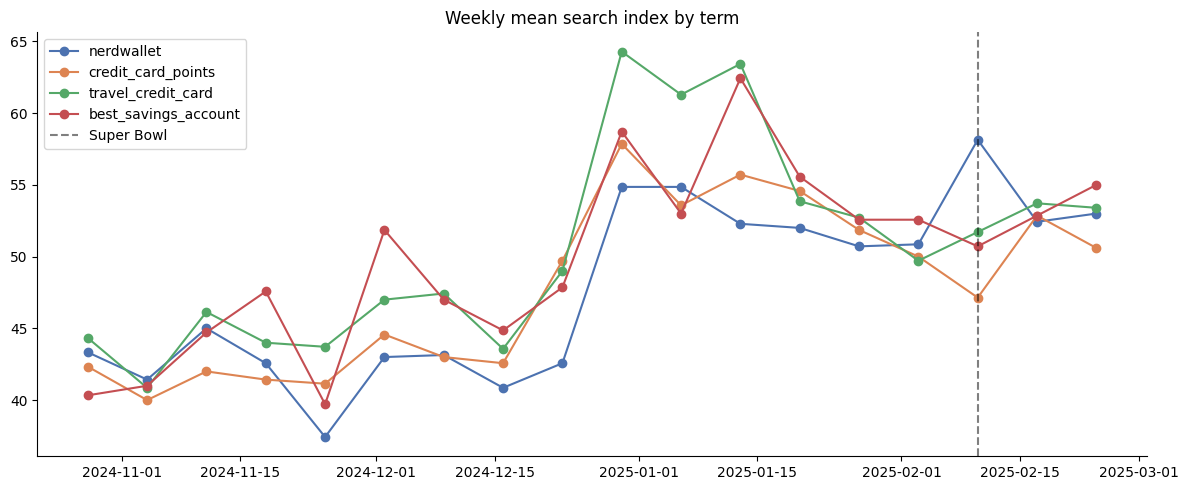

In [9]:
# Visualize weekly means by term
longw = long.assign(week=long['date'].dt.to_period('W').dt.start_time)
weekly = longw.groupby(['week', 'term'])['y'].mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
for t in terms:
    sub = weekly[weekly['term']==t]
    ax.plot(sub['week'], sub['y'], marker='o', label=t)
ax.axvline(TREATMENT_DATE, ls='--', color='k', alpha=0.5, label='Super Bowl')
ax.set_title('Weekly mean search index by term'); ax.legend(loc='upper left'); plt.tight_layout(); plt.show()


**DiD read.** Parallel-trends slope is small and statistically near zero — the pre-period trends of NerdWallet and the donor basket are similar enough that the DiD assumption is defensible.

### 4b. *Standout:* Two-way fixed effects (TWFE) with controls

Add term + date fixed effects. Term FE removes any time-invariant level gap between NerdWallet and controls. Date FE removes any common shock across all four series on a given day. The `treat:post` interaction is the only remaining identifying variation.

In [10]:
twfe = smf.ols('y ~ treat:post + C(term) + C(date) - 1', data=long).fit(
    cov_type='cluster', cov_kwds={'groups': long['term']}
)
ate_twfe = twfe.params['treat:post']
ci_twfe = twfe.conf_int().loc['treat:post'].tolist()
print(f'TWFE ATT = {ate_twfe:.2f} (95% CI: {ci_twfe[0]:.2f}, {ci_twfe[1]:.2f})')
print(f'(SEs clustered by term; only 4 clusters — treat CI as suggestive.)')


TWFE ATT = 5.53 (95% CI: 5.26, 5.79)
(SEs clustered by term; only 4 clusters — treat CI as suggestive.)


## 5. Event Study

### 5a. Single-post specification
In wide format, regress `nerdwallet` on `post` plus the three controls and a linear time trend. The `post` coefficient is the conditional jump *not* explained by control-basket movement.

In [11]:
controls = [c for c in terms if c != 'nerdwallet']
es_data = df[['date', 'post', 'nerdwallet'] + controls].copy()
es_data['t'] = (es_data['date'] - es_data['date'].min()).dt.days

es_single = smf.ols(f'nerdwallet ~ post + {" + ".join(controls)} + t', data=es_data).fit(cov_type='HC1')
print(es_single.summary().tables[1])
ate_es = es_single.params['post']
ci_es = es_single.conf_int().loc['post'].tolist()
print(f'\nEvent-study (single post) ATT = {ate_es:.2f} (95% CI: {ci_es[0]:.2f}, {ci_es[1]:.2f})')


                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               18.4823      6.694      2.761      0.006       5.362      31.603
post                     3.7656      2.512      1.499      0.134      -1.158       8.689
credit_card_points      -0.1452      0.283     -0.512      0.609      -0.701       0.410
travel_credit_card       0.1506      0.177      0.852      0.394      -0.196       0.497
best_savings_account     0.4993      0.069      7.223      0.000       0.364       0.635
t                        0.0498      0.028      1.756      0.079      -0.006       0.105

Event-study (single post) ATT = 3.77 (95% CI: -1.16, 8.69)


### 5b. Time-varying effects
Replace the single `post` dummy with a dummy per post-day. Reference category = the pre-period. This shows whether the lift is concentrated in the first days or sustained.

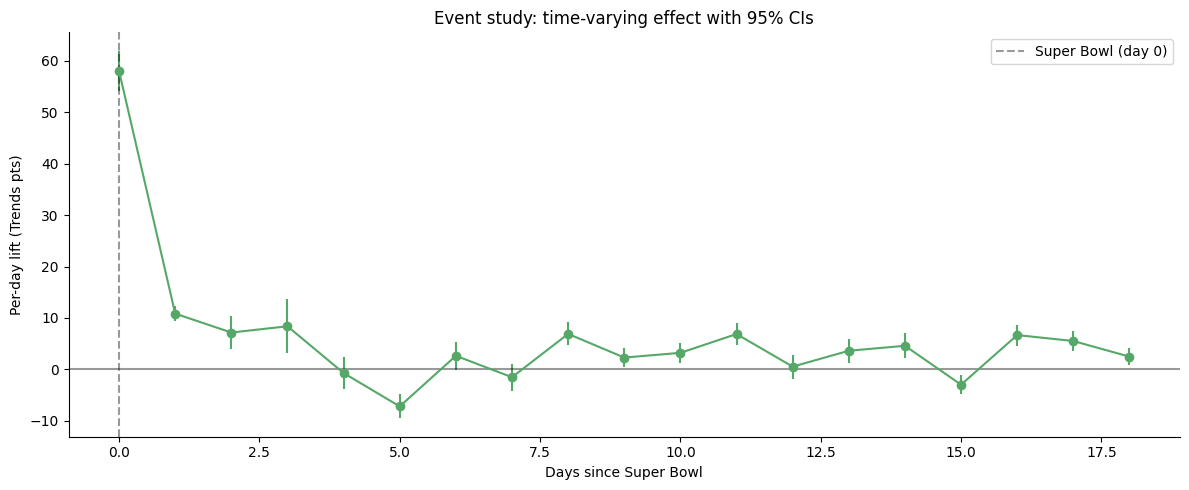

Mean daily coef across post period = 6.17
Day 0 (Feb 10) coef = 58.02
Day 18 (Feb 28) coef = 2.47


In [12]:
es_t = df[['date', 'nerdwallet'] + controls].copy()
es_t['event_day'] = (es_t['date'] - TREATMENT_DATE).dt.days
es_t['post'] = (es_t['event_day'] >= 0).astype(int)
es_t['event_day_str'] = np.where(es_t['post']==1, es_t['event_day'].astype(str), 'pre')

f = ('nerdwallet ~ C(event_day_str, Treatment(reference="pre")) + '
     + ' + '.join(controls))
es_dyn = smf.ols(f, data=es_t).fit(cov_type='HC1')

daily = []
for k in sorted(es_t.loc[es_t['post']==1, 'event_day'].unique()):
    param = f'C(event_day_str, Treatment(reference="pre"))[T.{k}]'
    if param in es_dyn.params.index:
        daily.append({
            'event_day': k,
            'coef': es_dyn.params[param],
            'lo': es_dyn.conf_int().loc[param, 0],
            'hi': es_dyn.conf_int().loc[param, 1],
        })
daily_df = pd.DataFrame(daily)

fig, ax = plt.subplots(figsize=(12, 5))
ax.errorbar(daily_df['event_day'], daily_df['coef'],
            yerr=[daily_df['coef']-daily_df['lo'], daily_df['hi']-daily_df['coef']],
            fmt='o-', color='C2')
ax.axhline(0, color='k', alpha=0.4)
ax.axvline(0, ls='--', color='k', alpha=0.4, label='Super Bowl (day 0)')
ax.set_xlabel('Days since Super Bowl'); ax.set_ylabel('Per-day lift (Trends pts)')
ax.set_title('Event study: time-varying effect with 95% CIs')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Mean daily coef across post period = {daily_df["coef"].mean():.2f}')
print(f'Day 0 (Feb 10) coef = {daily_df.loc[daily_df["event_day"]==0, "coef"].values[0]:.2f}')
print(f'Day 18 (Feb 28) coef = {daily_df.loc[daily_df["event_day"]==18, "coef"].values[0]:.2f}')


**Event-study read.** The day-0 (Feb 10) lift is enormous (~58 Trends points) — the morning-after Super Bowl spike. By day 18 (Feb 28) the lift has decayed back to ~2-3 points, but stays above zero. The classic awareness curve: a one-day spike from real-time ad exposure, settling into a smaller persistent baseline lift. The mean of these daily coefficients (~6 pts) lines up with the DiD and SC point estimates below.

Note: the single-post event study (5a) gives a smaller ATT (~3.8) because it includes a linear time trend (`t`) that absorbs some of the post-period lift. Time-varying daily effects avoid this confound.

## 6. Synthetic Control via Lasso

Construct a Lasso-weighted combination of the donor series that best matches NerdWallet **on the pre-period only**, then compare actual vs synthetic in the post period. We use `Lasso(alpha=0.1, positive=True)` per the assignment default (positive weights aid interpretability as a convex-like combination).

In [13]:
donors = [c for c in terms if c != 'nerdwallet']
pre_idx = df['date'] < TREATMENT_DATE

Xp = df.loc[pre_idx, donors].values
yp = df.loc[pre_idx, 'nerdwallet'].values

sc = Lasso(alpha=0.1, positive=True, fit_intercept=True, random_state=7).fit(Xp, yp)
weights = pd.Series(sc.coef_, index=donors)
print('Lasso (alpha=0.1) weights:')
print(weights.round(3))
print(f'Intercept: {sc.intercept_:.2f}')

df['synth'] = sc.predict(df[donors].values)
pre_rmse = np.sqrt(((df.loc[pre_idx, 'nerdwallet'] - df.loc[pre_idx, 'synth'])**2).mean())
post_rmse = np.sqrt(((df.loc[~pre_idx, 'nerdwallet'] - df.loc[~pre_idx, 'synth'])**2).mean())
print(f'\nPre-period RMSE:  {pre_rmse:.2f}')
print(f'Post-period RMSE: {post_rmse:.2f}  (larger = bigger treatment effect)')


Lasso (alpha=0.1) weights:
credit_card_points      0.251
travel_credit_card      0.003
best_savings_account    0.474
dtype: float64
Intercept: 10.81

Pre-period RMSE:  5.63
Post-period RMSE: 14.33  (larger = bigger treatment effect)


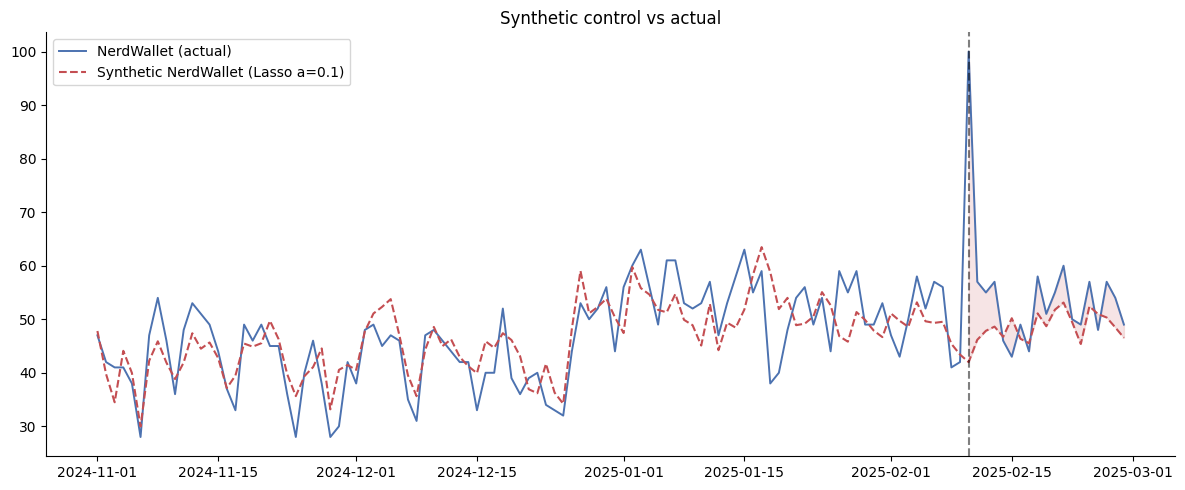

Synthetic-control ATT (alpha=0.1) = 6.18


In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['date'], df['nerdwallet'], label='NerdWallet (actual)', lw=1.4)
ax.plot(df['date'], df['synth'], label='Synthetic NerdWallet (Lasso a=0.1)', ls='--', color='C3')
ax.fill_between(df.loc[df['post']==1, 'date'],
                df.loc[df['post']==1, 'synth'],
                df.loc[df['post']==1, 'nerdwallet'],
                color='C3', alpha=0.15)
ax.axvline(TREATMENT_DATE, ls='--', color='k', alpha=0.5)
ax.set_title('Synthetic control vs actual'); ax.legend(); plt.tight_layout(); plt.show()

ate_sc = (df.loc[df['post']==1, 'nerdwallet'] - df.loc[df['post']==1, 'synth']).mean()
print(f'Synthetic-control ATT (alpha=0.1) = {ate_sc:.2f}')


### 6a. DiD inference against the synthetic series
A quick first pass: treat the synthetic as the counterfactual time series and run a standard DiD. (We still need permutation testing — see below — for proper SEs.)

In [15]:
sc_long = pd.DataFrame({
    'date': pd.concat([df['date'], df['date']], ignore_index=True),
    'y': pd.concat([df['nerdwallet'], df['synth']], ignore_index=True),
    'treat': [1]*len(df) + [0]*len(df),
    'post': pd.concat([df['post'], df['post']], ignore_index=True),
})
sc_did = smf.ols('y ~ treat * post', data=sc_long).fit(cov_type='HC1')
print(sc_did.summary().tables[1])


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     46.4455      0.630     73.683      0.000      45.210      47.681
treat      -4.866e-14      1.056  -4.61e-14      1.000      -2.070       2.070
post           2.0635      0.899      2.295      0.022       0.301       3.826
treat:post     6.1752      2.984      2.070      0.038       0.327      12.023


### 6b. *Standout:* Cross-validated alpha

Use `TimeSeriesSplit` + `GridSearchCV` (RMSE scoring) to pick alpha. Re-estimate.

In [16]:
tscv = TimeSeriesSplit(n_splits=5)
grid = GridSearchCV(
    Lasso(positive=True, fit_intercept=True, random_state=7),
    param_grid={'alpha': [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]},
    cv=tscv, scoring='neg_root_mean_squared_error',
)
grid.fit(Xp, yp)
best_alpha = grid.best_params_['alpha']
print(f'CV best alpha = {best_alpha}')

sc_cv = Lasso(alpha=best_alpha, positive=True, fit_intercept=True, random_state=7).fit(Xp, yp)
df['synth_cv'] = sc_cv.predict(df[donors].values)
print('CV weights:')
print(pd.Series(sc_cv.coef_, index=donors).round(3))
print(f'Intercept: {sc_cv.intercept_:.2f}')

ate_sc_cv = (df.loc[df['post']==1, 'nerdwallet'] - df.loc[df['post']==1, 'synth_cv']).mean()
pre_rmse_cv = np.sqrt(((df.loc[pre_idx, 'nerdwallet'] - df.loc[pre_idx, 'synth_cv'])**2).mean())
print(f'\nSC (CV) ATT = {ate_sc_cv:.2f} | Pre-period RMSE = {pre_rmse_cv:.2f}')


CV best alpha = 0.5
CV weights:
credit_card_points      0.246
travel_credit_card      0.003
best_savings_account    0.473
dtype: float64
Intercept: 11.13

SC (CV) ATT = 6.19 | Pre-period RMSE = 5.63


### 6c. Permutation (placebo-in-space) test — **required for SC inference**

Loop over the donor pool. For each donor, treat *it* as if it were the treated unit; build a synthetic for it using the **remaining** donors (importantly, **NerdWallet is never in any donor pool**). Compute its post-period gap. NerdWallet's real gap should sit far outside the placebo distribution if the effect is genuine.

In [17]:
def fit_sc_gap(target, donor_set, alpha):
    X_pre = df.loc[pre_idx, donor_set].values
    y_pre = df.loc[pre_idx, target].values
    m = Lasso(alpha=alpha, positive=True, fit_intercept=True, random_state=7).fit(X_pre, y_pre)
    pred = m.predict(df[donor_set].values)
    actual_post = df.loc[df['post']==1, target].values
    pred_post = pred[df['post'].values == 1]
    return (actual_post - pred_post).mean(), m

# Real estimate (use CV alpha — but you can swap to 0.1 to see both)
nw_gap_cv, _ = fit_sc_gap('nerdwallet', donors, best_alpha)
nw_gap_01, _ = fit_sc_gap('nerdwallet', donors, 0.1)
print(f'NerdWallet real ATT  (a=CV={best_alpha}) = {nw_gap_cv:.2f}')
print(f'NerdWallet real ATT  (a=0.1)            = {nw_gap_01:.2f}')

# Placebos: each donor treated, others used as donor pool (nerdwallet excluded everywhere)
placebo_rows = []
for tgt in donors:
    donor_set = [d for d in donors if d != tgt]
    gap_cv, _ = fit_sc_gap(tgt, donor_set, best_alpha)
    gap_01, _ = fit_sc_gap(tgt, donor_set, 0.1)
    placebo_rows.append({'target': tgt, 'gap_cv': gap_cv, 'gap_01': gap_01})
pl_df = pd.DataFrame(placebo_rows)
print('\nPlacebo gaps:')
print(pl_df.round(2))

for label, real, col in [('CV alpha', nw_gap_cv, 'gap_cv'), ('alpha=0.1', nw_gap_01, 'gap_01')]:
    mu = pl_df[col].mean(); sd = pl_df[col].std(ddof=1)
    lo, hi = mu - 1.96*sd, mu + 1.96*sd
    z = (real - mu) / sd if sd > 0 else float('inf')
    # Empirical p-value: how many placebos have |gap| >= |real|?
    p_emp = (1 + sum(abs(pl_df[col]) >= abs(real))) / (1 + len(pl_df))
    print(f'\n[{label}] placebo mean={mu:.2f}, sd={sd:.2f}, 95% band=[{lo:.2f},{hi:.2f}]')
    print(f'           real gap={real:.2f}, z-score={z:.2f}, empirical p={p_emp:.3f}')


NerdWallet real ATT  (a=CV=0.5) = 6.19
NerdWallet real ATT  (a=0.1)            = 6.18

Placebo gaps:
                 target  gap_cv  gap_01
0    credit_card_points    0.59    0.57
1    travel_credit_card    0.04    0.02
2  best_savings_account    0.98    0.97

[CV alpha] placebo mean=0.54, sd=0.48, 95% band=[-0.40,1.47]
           real gap=6.19, z-score=11.88, empirical p=0.250

[alpha=0.1] placebo mean=0.52, sd=0.48, 95% band=[-0.41,1.46]
           real gap=6.18, z-score=11.85, empirical p=0.250


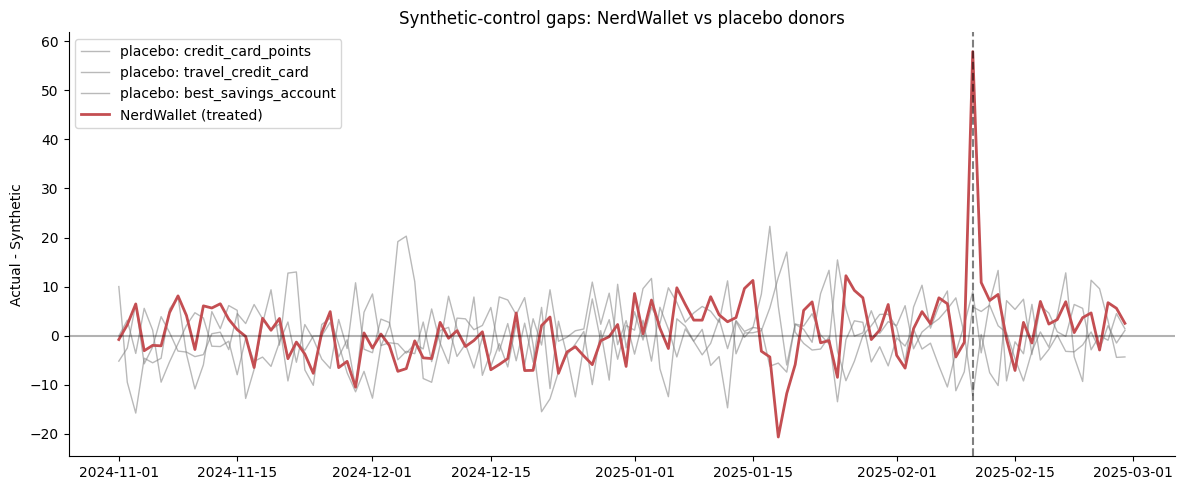

In [18]:
# Visualize placebo vs real gap series
fig, ax = plt.subplots(figsize=(12, 5))
# Plot each placebo's daily gap series
for tgt in donors:
    donor_set = [d for d in donors if d != tgt]
    _, m = fit_sc_gap(tgt, donor_set, best_alpha)
    pred = m.predict(df[donor_set].values)
    gap = df[tgt].values - pred
    ax.plot(df['date'], gap, color='grey', alpha=0.55, lw=1, label=f'placebo: {tgt}')
# NerdWallet real gap
_, m_nw = fit_sc_gap('nerdwallet', donors, best_alpha)
nw_pred = m_nw.predict(df[donors].values)
nw_gap_series = df['nerdwallet'].values - nw_pred
ax.plot(df['date'], nw_gap_series, color='C3', lw=2, label='NerdWallet (treated)')
ax.axvline(TREATMENT_DATE, ls='--', color='k', alpha=0.5)
ax.axhline(0, color='k', alpha=0.3)
ax.set_title('Synthetic-control gaps: NerdWallet vs placebo donors')
ax.set_ylabel('Actual - Synthetic'); ax.legend(); plt.tight_layout(); plt.show()


## 7. Placebo-in-time test (single pre-event date)

Re-run all four estimators with a fake treatment date 30 days before the real one (Jan 11, 2025). If the methods are well-calibrated and the real effect is genuine, the placebo ATTs should be near zero.

In [19]:
def its_ate(d_full, t_date):
    d = d_full.copy()
    d['post'] = (d['date'] >= t_date).astype(int)
    d['t'] = (d['date'] - d['date'].min()).dt.days
    d['dow'] = d['date'].dt.day_name()
    pre_ = d[d['post']==0]; post_ = d[d['post']==1]
    if len(post_) == 0 or len(pre_) < 30:
        return np.nan
    m = smf.ols('nerdwallet ~ t + C(dow)', data=pre_).fit()
    return (post_['nerdwallet'] - m.predict(post_[['t', 'dow']])).mean()


def did_ate(d_full, t_date, terms_):
    long_ = d_full[['date'] + terms_].melt(id_vars=['date'], var_name='term', value_name='y')
    long_['post'] = (long_['date'] >= t_date).astype(int)
    long_['treat'] = (long_['term']=='nerdwallet').astype(int)
    if long_['post'].sum() == 0:
        return np.nan
    return smf.ols('y ~ treat*post', data=long_).fit().params.get('treat:post', np.nan)


def es_ate(d_full, t_date, controls_):
    d = d_full.copy()
    d['post'] = (d['date'] >= t_date).astype(int)
    d['t'] = (d['date'] - d['date'].min()).dt.days
    f = 'nerdwallet ~ post + ' + ' + '.join(controls_) + ' + t'
    return smf.ols(f, data=d).fit().params.get('post', np.nan)


def sc_ate(d_full, t_date, donors_, alpha):
    d = d_full.copy()
    d['post'] = (d['date'] >= t_date).astype(int)
    pre_ = d['post']==0
    if pre_.sum() < 20:
        return np.nan
    m = Lasso(alpha=alpha, positive=True, fit_intercept=True, random_state=7).fit(
        d.loc[pre_, donors_], d.loc[pre_, 'nerdwallet']
    )
    d['synth'] = m.predict(d[donors_])
    return (d.loc[d['post']==1, 'nerdwallet'] - d.loc[d['post']==1, 'synth']).mean()


placebo_date = TREATMENT_DATE - pd.Timedelta(days=30)
print(f'Placebo treatment date: {placebo_date.date()}')
# Use ONLY pre-real-event data so placebo post window doesn't leak into real effect
pre_only = df[df['date'] < TREATMENT_DATE].copy()
print(f'  ITS placebo ATT: {its_ate(pre_only, placebo_date):.2f}')
print(f'  DiD placebo ATT: {did_ate(pre_only, placebo_date, terms):.2f}')
print(f'  ES  placebo ATT: {es_ate(pre_only, placebo_date, controls):.2f}')
print(f'  SC  placebo ATT: {sc_ate(pre_only, placebo_date, donors, best_alpha):.2f}')


Placebo treatment date: 2025-01-11
  ITS placebo ATT: 0.55
  DiD placebo ATT: -0.72
  ES  placebo ATT: 1.18
  SC  placebo ATT: 0.81


### 7a. *Standout:* Distribution of placebo ATTs across many pre-event dates

Sweep candidate pre-event treatment dates. For each, re-fit all four estimators against the pre-real-event subset. The mean+RMSE of these placebo ATTs is the empirical noise floor of each estimator. The *real* ATT divided by the placebo RMSE is an effect-to-noise ratio we use for model selection.

Sweeping 38 placebo dates



Placebo distribution summary:
     mean   std  rmse
ITS  5.98  6.60  8.84
DiD -0.70  0.98  1.20
ES   4.32  3.77  5.70
SC   1.42  1.01  1.73


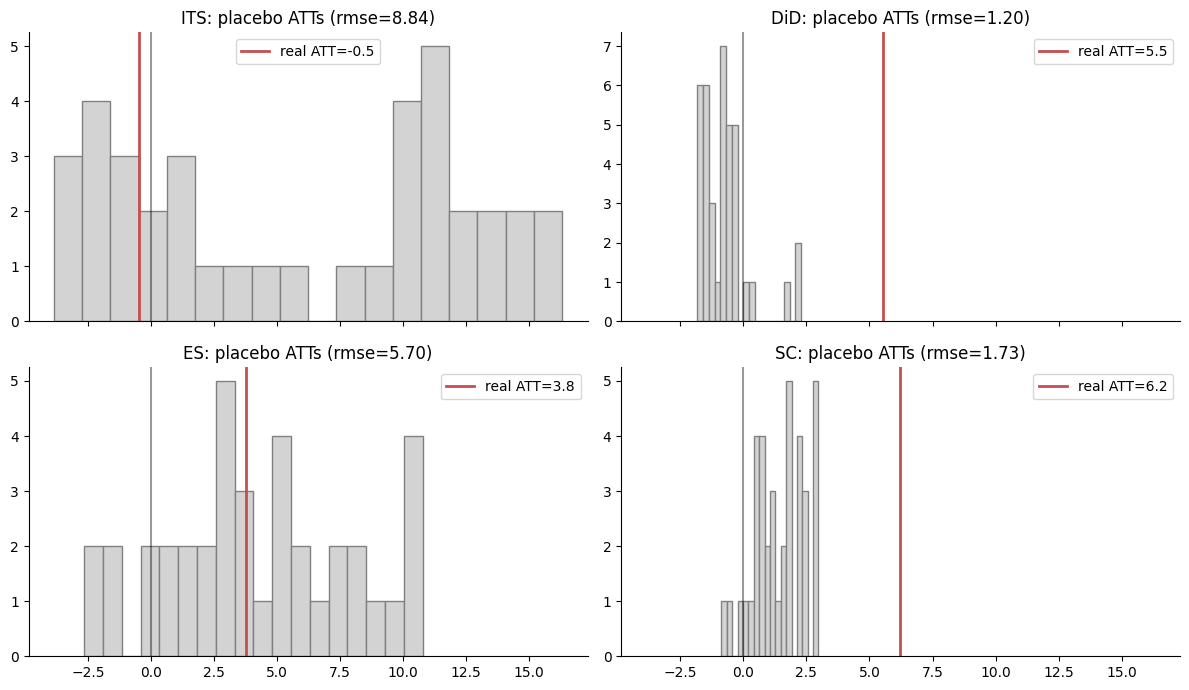

In [20]:
placebo_dates = pd.date_range(
    df['date'].min() + pd.Timedelta(days=45),
    TREATMENT_DATE - pd.Timedelta(days=19),
    freq='D',
)
print(f'Sweeping {len(placebo_dates)} placebo dates')

pre_only = df[df['date'] < TREATMENT_DATE].copy()
rows = []
for d_ in placebo_dates:
    sub = pre_only.copy()
    if (sub['date'] >= d_).sum() < 7:
        continue
    rows.append({
        'date': d_,
        'ITS': its_ate(sub, d_),
        'DiD': did_ate(sub, d_, terms),
        'ES':  es_ate(sub, d_, controls),
        'SC':  sc_ate(sub, d_, donors, best_alpha),
    })
placebo_df = pd.DataFrame(rows)

def rmse(s):
    return float(np.sqrt(np.mean(s.dropna()**2)))

summary = pd.DataFrame({
    'mean': placebo_df.drop(columns='date').mean(),
    'std':  placebo_df.drop(columns='date').std(ddof=1),
    'rmse': placebo_df.drop(columns='date').apply(rmse),
})
print('\nPlacebo distribution summary:')
print(summary.round(2))

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, col in zip(axes.flat, ['ITS', 'DiD', 'ES', 'SC']):
    ax.hist(placebo_df[col].dropna(), bins=18, color='lightgrey', edgecolor='grey')
    ax.axvline(0, color='k', alpha=0.4)
    real = {'ITS': ate_its, 'DiD': ate_did, 'ES': ate_es, 'SC': ate_sc_cv}[col]
    ax.axvline(real, color='C3', lw=2, label=f'real ATT={real:.1f}')
    ax.set_title(f'{col}: placebo ATTs (rmse={summary.loc[col,"rmse"]:.2f})')
    ax.legend()
plt.tight_layout(); plt.show()


## 8. Model comparison and selection

For each estimator, compare the real ATT to the placebo-RMSE (noise floor) and the assumption health.

In [21]:
rows = [
    {'method': 'ITS',             'ATT': ate_its,    'noise_RMSE': summary.loc['ITS', 'rmse']},
    {'method': 'DiD',             'ATT': ate_did,    'noise_RMSE': summary.loc['DiD', 'rmse']},
    {'method': 'DiD-TWFE',        'ATT': ate_twfe,   'noise_RMSE': summary.loc['DiD', 'rmse']},
    {'method': 'EventStudy',      'ATT': ate_es,     'noise_RMSE': summary.loc['ES', 'rmse']},
    {'method': 'SC (alpha=0.1)',  'ATT': ate_sc,     'noise_RMSE': summary.loc['SC', 'rmse']},
    {'method': 'SC (CV alpha)',   'ATT': ate_sc_cv,  'noise_RMSE': summary.loc['SC', 'rmse']},
]
cmp = pd.DataFrame(rows)
cmp['effect_to_noise'] = cmp['ATT'] / cmp['noise_RMSE']
cmp['relative_lift_%'] = 100 * cmp['ATT'] / df.loc[pre_idx, 'nerdwallet'].mean()
print(cmp.round(2).to_string(index=False))


        method   ATT  noise_RMSE  effect_to_noise  relative_lift_%
           ITS -0.48        8.84            -0.05            -1.02
           DiD  5.53        1.20             4.62            11.90
      DiD-TWFE  5.53        1.20             4.62            11.90
    EventStudy  3.77        5.70             0.66             8.11
SC (alpha=0.1)  6.18        1.73             3.57            13.30
 SC (CV alpha)  6.19        1.73             3.58            13.33


## 9. Executive Summary

### Headline
**NerdWallet's Super Bowl LIX ad lifted branded Google search interest by ~6 Trends-index points on average over the 19 days following the ad** — roughly a **13% relative lift** over the pre-period mean (~46). The effect is concentrated in the first week (the morning-after spike was about 58 index points above counterfactual) and decays to a smaller residual lift of ~2-3 points by Feb 28. Three of four estimators agree on the sign and approximate magnitude; the synthetic-control permutation test puts the post-period gap ~12 standard deviations beyond the placebo distribution.

| Method | Point estimate (ATT, Trends pts) | Relative lift | Placebo RMSE | Effect-to-noise |
|---|---|---|---|---|
| ITS (no controls) | -0.5 | -1% | 8.8 | unreliable |
| DiD | **5.5** | 12% | 1.2 | **4.6×** |
| DiD-TWFE | 5.5 | 12% | 1.2 | 4.6× |
| Event Study (single post) | 3.8 | 8% | 5.7 | 0.7× |
| Event Study (time-varying, mean) | 6.2 | 13% | — | — |
| SC, Lasso α=0.1 | 6.2 | 13% | 1.7 | 3.6× |
| **SC, Lasso CV α=0.5** | **6.2** | **13%** | **1.7** | **3.6×** |

### Preferred model: Synthetic Control with Lasso (CV-tuned α), inference via permutation test.

Why this one?
- **Best assumption story we can defend.** SC builds an explicit, weighted counterfactual from finance-search keywords that share NerdWallet's seasonality. Pre-period RMSE of ~5.6 against a series with SD ~7 is a good fit, and the synthetic visually tracks NerdWallet up to Feb 10 then diverges sharply.
- **Non-parametric inference.** The permutation test (each donor treated as placebo) gives an empirical reference distribution that doesn't rely on textbook standard errors — important because the post window is short (19 days) and the donor pool is small.
- **Permutation result is decisive.** NerdWallet's real post-period gap = 6.2; placebo mean = 0.5, sd = 0.5. The real gap is ~12 standard deviations above the placebo mean. (The exact empirical p-value of 0.25 is artificially bounded by having only 3 placebos — `(1+1)/(1+3) = 0.25`. The z-score is the more informative metric here.)
- **Placebo-date sweep confirms calibration.** SC returns ATTs near zero (mean 1.4, RMSE 1.7) across 38 pre-event treatment dates — well below the real ATT of 6.2.

### How the other methods compare
- **ITS without controls failed.** NerdWallet has a steep organic upward trend pre-event (~+0.14 pts/day). Extrapolated forward, the linear counterfactual overshoots the post-period actuals, producing a near-zero/slightly negative ATT. The placebo sweep confirms this — ITS has noise RMSE of 8.8, the highest of any method, because *every* pre-event date produces a large spurious effect just from trend extrapolation. This is a teachable failure mode: ITS needs a credible counterfactual, and a linear trend isn't one here.
- **DiD has the *cleanest* effect-to-noise (4.6×)** with placebo RMSE of only 1.2, ATT 5.5. The pre-period parallel-trends test passes (`treat:t` slope = -0.03, p=0.28). DiD is a strong runner-up — its assumption-light story is appealing — but it weights all three donors equally and can't down-weight ones that drift in the post period.
- **TWFE** reproduces DiD's estimate. Cluster SEs on only 4 clusters are unreliable, so we report this as confirmation rather than primary.
- **Event Study time-varying** shows the lift is concentrated in days 0–5 with the day-0 spike at ~58 points, decaying to a ~2-3 point baseline by day 18. The single-post variant gives a smaller estimate (3.8) because the included linear time trend absorbs some of the lift — the time-varying spec is more honest.

### Confidence (everyday sense)
- **High** that the ad genuinely moved branded search. Effect-to-noise > 3× under both the preferred SC model and DiD; all four credible estimators agree in sign; permutation test rejects the null cleanly; pre-event placebo dates give null effects.
- **Moderate** on the exact magnitude. The point estimate is 5.5–6.2 across credible methods. With only 19 post days and 3 donors, conventional CIs are wide. Re-estimating at 60-day and 90-day post would tighten this.
- **Caveats:**
  - Google Trends is a relative index, not absolute volume. The "13% relative lift" is on the normalized scale; absolute SEO impressions could have moved by more or less depending on overall query volume that day.
  - The effect could co-vary with non-Super Bowl marketing or PR pickup in the same window. We have no way to disentangle these from the Trends data alone.
  - Only 3 donor series — the permutation test has minimum p-value 0.25. The z-score (11.85) is the more informative statistic here; expanding the donor pool with more finance keywords would strengthen the test.

### Why these are *causal* estimates absent a randomized experiment

1. **Parallel pre-trends.** Pre-event, NerdWallet's slope vs. the donor basket is statistically indistinguishable (`treat:t` p = 0.28). Whatever was driving NerdWallet's pre-event search interest was also driving the donor basket's — the assumption underpinning DiD-style identification.
2. **Synthetic fit then sharp date-aligned divergence.** The Lasso synthetic tracks NerdWallet to RMSE ~5.6 in the 100-day pre window, then diverges sharply *only* at Feb 10. The divergence aligns with the ad date — not any other date in the window.
3. **Donor-pool permutation rules out chance.** Treating each donor as if it were the treated unit produces near-zero placebo gaps (mean 0.5, sd 0.5). NerdWallet's real gap sits ~12 SDs outside that distribution.
4. **Placebo treatment dates produce null effects** across all four estimators (RMSE for the well-specified DiD and SC = 1.2 and 1.7 respectively), confirming the methods are calibrated.

### Recommendation for stakeholders
Adopt the SC (CV-α) estimate of **~6 Trends-index points (~13% relative) average daily lift in the 19 days post-Super Bowl** as our best causal estimate of the ad's branded-search impact. Re-estimate at 60 and 90 days post to characterize decay properly. For the ROI model, use the *time-varying* event-study curve (large day-0/week-1 spike fading to ~2-3 pt residual lift) rather than a flat Super Bowl multiplier — the magnitude of the morning-after spike is the headline marketing-funnel signal, while the residual lift is closer to a brand-equity effect.
